<a href="https://colab.research.google.com/github/Sergei-N-Fedorov/Data_Analysis/blob/main/IntroDL_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Image classification with CNN

The goal is to build and fine-tune a convolutional neural network to classify small images.

In [ ]:
# libraries and modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tensorflow.keras import datasets, layers, models, callbacks, optimizers, losses
from sklearn.model_selection import train_test_split

import os
from google.colab import drive
import pickle
import csv

import itertools
import random

In [ ]:
# Storing results
drive.mount('/content/drive')
RESULTS_PATH = "/content/drive/MyDrive/cnn_project_results.csv"

Mounted at /content/drive


## Data

The source of data is the CIFAR-100 dataset that consists of colour images $32 \times 32$.

A subset of the dataset is extracted:

* 10 classes,
* in each class:
  * 300 images for training,
  * 60 images for validation,
  * 60 images for testing.

(The full dataset contains 60000 images evenly distributed in 100 classes.)

In [ ]:
# load the data
(X_train, y_train), (X_test, y_test) = datasets.cifar100.load_data()

print(X_train.shape)
print(X_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


In [ ]:
print(y_train.shape)
print(y_test.shape)

(50000, 1)
(10000, 1)


In [ ]:
# The list of the CIFAR-100 class names
class_names = [
    "apple",
    "aquarium_fish",
    "baby",
    "bear",
    "beaver",
    "bed",
    "bee",
    "beetle",
    "bicycle",
    "bottle",
    "bowl",
    "boy",
    "bridge",
    "bus",
    "butterfly",
    "camel",
    "can",
    "castle",
    "caterpillar",
    "cattle",
    "chair",
    "chimpanzee",
    "clock",
    "cloud",
    "cockroach",
    "couch",
    "crab",
    "crocodile",
    "cup",
    "dinosaur",
    "dolphin",
    "elephant",
    "flatfish",
    "forest",
    "fox",
    "girl",
    "hamster",
    "house",
    "kangaroo",
    "keyboard",
    "lamp",
    "lawn_mower",
    "leopard",
    "lion",
    "lizard",
    "lobster",
    "man",
    "maple",
    "motorcycle",
    "mountain",
    "mouse",
    "mushroom",
    "oak",
    "orange",
    "orchid",
    "otter",
    "palm",
    "pear",
    "pickup_truck",
    "pine",
    "plain",
    "plate",
    "poppy",
    "porcupine",
    "possum",
    "rabbit",
    "raccoon",
    "ray",
    "road",
    "rocket",
    "rose",
    "sea",
    "seal",
    "shark",
    "shrew",
    "skunk",
    "skyscraper",
    "snail",
    "snake",
    "spider",
    "squirrel",
    "streetcar",
    "sunflower",
    "sweet_pepper",
    "table",
    "tank",
    "telephone",
    "television",
    "tiger",
    "tractor",
    "train",
    "trout",
    "tulip",
    "turtle",
    "wardrobe",
    "whale",
    "willow",
    "wolf",
    "woman",
    "worm",
]

# dictionary mapping class names to their numerical labels
cls_name2idx = {class_names[i]: i for i in range(len(class_names))}

Here are some examples of the dataset images:

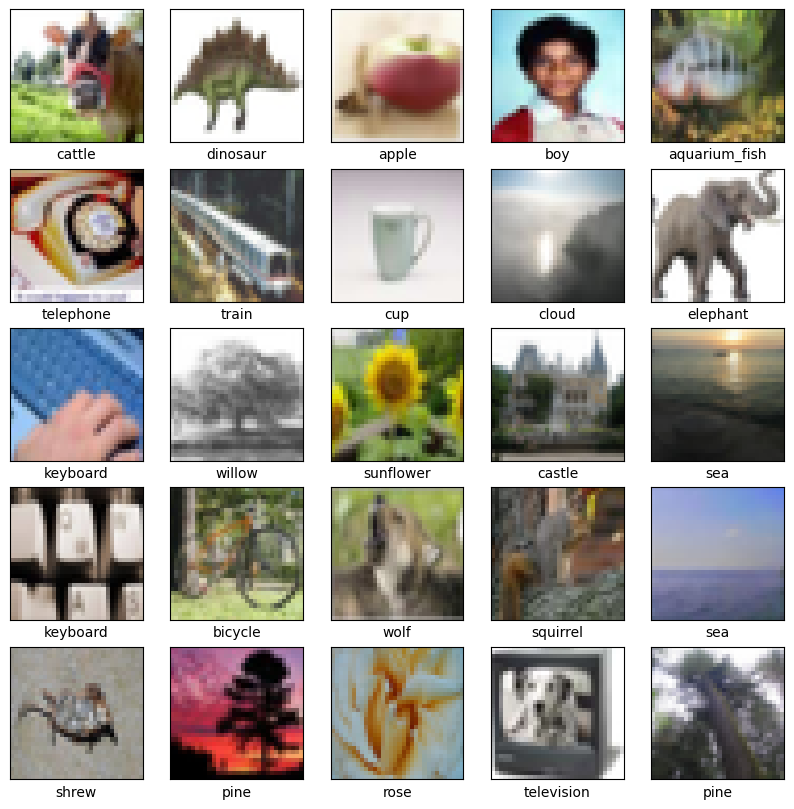

In [ ]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i])
    plt.xlabel(class_names[y_train[i][0]])
plt.show()

We split the training part into training and validation sets to avoid data leakage during hyperparameter tuning.

In [ ]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train, y_train,
    test_size = 0.2,
    stratify = y_train,
    random_state = 100
)

In [ ]:
print(X_train.shape[0])
print(X_valid.shape[0])
print(y_train.shape)
print(y_valid.shape)

40000
10000
(40000, 1)
(10000, 1)


In [ ]:
# downsampling

def sample_images(X, y, classes, class_size):
    '''
    classes: list of class names being in the sample
    class_size: the target number of images per class
    '''
    X_sample = []
    y_sample = []
    for c in range(len(classes)):
        ids = [i for i in range(len(y)) if y[i] == cls_name2idx[classes[c]]]
        ids = np.random.choice(ids, size = class_size, replace = False) # select a subset
        X_sample.extend(X[ids])
        y_sample.extend([c] * len(ids))

    X_sample = np.array(X_sample)
    y_sample = np.array(y_sample)

    # shuffle the sample (initially the examples are grouped by class)
    perm = np.random.permutation(len(X_sample))

    return X_sample[perm], y_sample[perm]

In [ ]:
# Select 10 classes out of 100
sample_classes = ["aquarium_fish", "sunflower", "orange", "lamp", "bee", "tiger", "camel", "squirrel", "pine", "bus"]
sample_cls_name2idx = {sample_classes[i]: i for i in range(len(sample_classes))} # map class name to its label 0-9
n_classes = len(sample_classes) # current number of classes

# downsampled dataset
X_trn, y_trn = sample_images(X_train,
                      y_train,
                      sample_classes,
                      300
                     )
X_val, y_val = sample_images(X_valid,
                      y_valid,
                      sample_classes,
                      60
                     )
X_tst, y_tst = sample_images(X_test,
                      y_test,
                      sample_classes,
                      60
                     )
print(X_trn.shape)
print(y_trn.shape)
print(X_tst.shape)
print(y_tst.shape)

(3000, 32, 32, 3)
(3000,)
(600, 32, 32, 3)
(600,)


In [ ]:
# Normalize pixel values to be between 0 and 1
X_trn, X_val, X_tst = X_trn / 255.0, X_val / 255.0, X_tst / 255.0

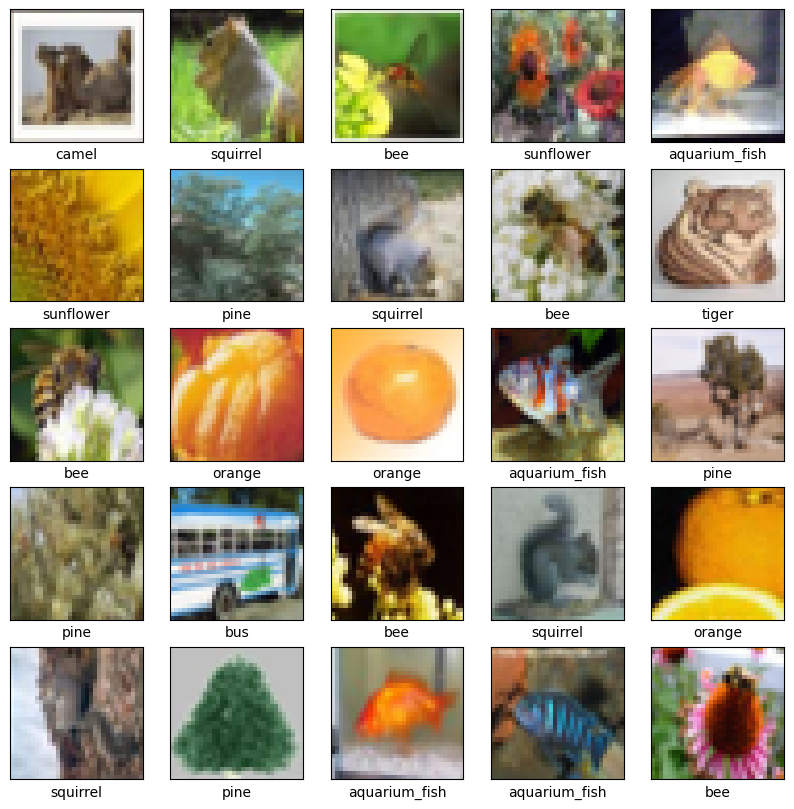

In [ ]:
# Show examples of the sample images

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_trn[i])
    plt.xlabel(sample_classes[y_trn[i]])
plt.show()

## Model

We use [the Tensorflow tutorial example](https://www.tensorflow.org/tutorials/images/cnn) as the base model and first train it on the given sample.

### Structure

In [ ]:
# The model definition
model = models.Sequential()
model.add(layers.Input(shape = (32, 32, 3)))
model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(n_classes))

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Compile the model
model.compile(optimizer = 'adam',
              loss = losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics = ['accuracy'])

early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5)

### Training

In [ ]:
history = model.fit(X_trn, y_trn,
                    epochs = 50,
                    batch_size = 10,
                    callbacks = [early_stopping],
                    validation_data = (X_val, y_val)
                   )

Epoch 1/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 20ms/step - accuracy: 0.3097 - loss: 1.8915 - val_accuracy: 0.4267 - val_loss: 1.6399
Epoch 2/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.4810 - loss: 1.5169 - val_accuracy: 0.5417 - val_loss: 1.4219
Epoch 3/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5737 - loss: 1.2701 - val_accuracy: 0.4967 - val_loss: 1.4992
Epoch 4/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6283 - loss: 1.0964 - val_accuracy: 0.5617 - val_loss: 1.3952
Epoch 5/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6860 - loss: 0.9420 - val_accuracy: 0.5633 - val_loss: 1.3783
Epoch 6/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.7093 - loss: 0.8322 - val_accuracy: 0.5767 - val_loss: 1.3141
Epoch 7/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.7663 - loss: 0.6993 - val_accuracy: 0.5533 - val_loss: 1.4518
Epoch 8/50
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - accuracy: 0.8097 - loss: 0.5758 - val_accu

### Evaluation

For convenience, we define a function that draw the plot with training and validation accuracies across epochs which are "pulled" out from the training history of a model.

In [ ]:
def eval_show(model, history, X_test, y_test):
    plt.plot(history['accuracy'], label = 'train accuracy')
    plt.plot(history['val_accuracy'], label = 'valid. accuracy')
    plt.xlabel('epoch')
    plt.ylabel('accuracy')
    plt.ylim([0, 1])
    plt.hlines(y = 0.6, xmin = 0, xmax = len(history['accuracy']), linestyles = 'dashed')
    plt.legend(loc = 'lower right')
    plt.title('Training history')
    plt.show()

    _, test_acc = model.evaluate(X_test, y_test, verbose = False)
    print(f"\nAccuracy of the trained model: {test_acc:.4f}")

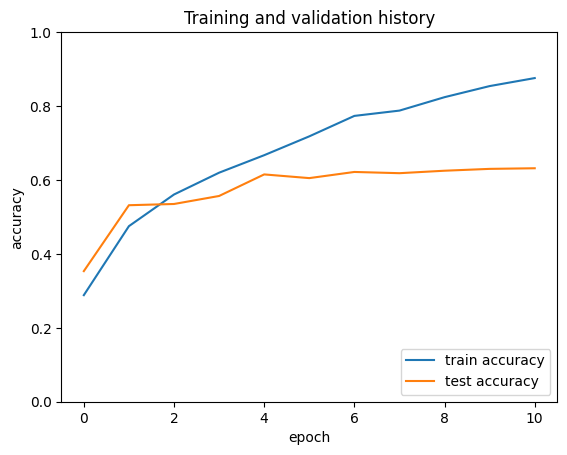


Accuracy of the trained model on the test set: 0.6317


In [ ]:
eval_show(model, history.history, X_tst, y_tst)

Here and below for the architectures under experiments, the blue plot is for training data, the red one is for validation data, and the final value of accuracy (beneath the plots) is for already trained models on test data.

## Experiments

The goal is to build a model with a certain set of hyperparameters that would perform better than the previous one.

First, we try several architectures of the CNN classificator, i.e., we choose other sequences of layers and set different shapes of them.

Then we try different options for hyperparameters:

* activation function

* optimizer

* learning rate

and training settings:

* batch size

* number of epochs

We will only try few values of parameters for only two architectures because otherwise it would lead to too large amount of computations.

### Architectures

In this section, several models are constructed that differ by their layer sets and layer sizes.
Other parameters are same:

* activation ReLU,

* optimizer Adam

* learning rate 0.001,

they are trained with batch size 10 and maximum 16 epochs.

This is done to compare those architectures to each other in equal conditions.

#### Model 1: the tutorial example extended

We just double the number of filters in the third convolutional layer and add an extra fully connected layer with 32 hidden units right before the output layer.

In [ ]:
# Model 1 (extended version of the initial model)
model1 = models.Sequential([
  layers.Input(shape = (32, 32, 3)),
  layers.Conv2D(32, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(128, (3, 3), activation='relu'),  # changed: 64 -> 128
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(32, activation='relu'),            # added
  layers.Dense(n_classes)
])
model1.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       131,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 226,794 (885.91 KB)

 Trainable params: 226,794 (885.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - accuracy: 0.2220 - loss: 2.0381 - val_accuracy: 0.2183 - val_loss: 1.9719
Epoch 2/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.3890 - loss: 1.7041 - val_accuracy: 0.4450 - val_loss: 1.5718
Epoch 3/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - accuracy: 0.4737 - loss: 1.5020 - val_accuracy: 0.4667 - val_loss: 1.4889
Epoch 4/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5120 - loss: 1.3949 - val_accuracy: 0.4850 - val_loss: 1.5496
Epoch 5/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.5687 - loss: 1.2440 - val_accuracy: 0.4867 - val_loss: 1.4592
Epoch 6/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.6257 - loss: 1.0946 - val_accuracy: 0.5117 - val_loss: 1.5830
Epoch 7/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 20ms/step - accuracy: 0.6717 - loss: 0.9597 - val_accuracy: 0.5567 - val_loss: 1.4294
Epoch 8/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - accuracy: 0.7180 - loss: 0.8163 - val_ac

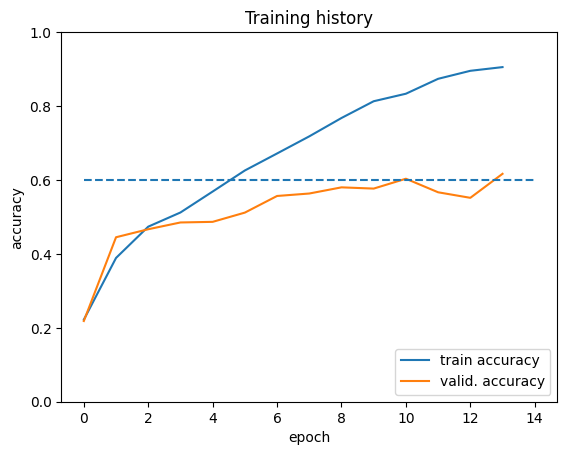


Accuracy of the trained model: 0.5767


In [ ]:
model1.compile(optimizer = 'adam',
              loss = losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics = ['accuracy'])

early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5)

history1 = model1.fit(X_trn, y_trn,
                    epochs = 16,
                    batch_size = 10,
                    callbacks = [early_stopping],
                    validation_data = (X_val, y_val)
                   )
eval_show(model1, history1.history, X_tst, y_tst)

The similar plot. But the final accuracy (in the test set) is lower.

#### Model 2: a reduced variant

With respect to the previous setting, the second model has less filters (16) in the first convolution layer, less in the last one (96), and wider filters (5x5) in the first layer. Also, we have the average pooling layer after the last convolution layer

In [ ]:
# Model 2
model2 = models.Sequential([
  layers.Conv2D(16, (5, 5), activation='relu', input_shape=(32, 32, 3)), # 32 -> 16 filters, 3 -> 5 filter size
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(32, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(96, (3, 3), activation='relu'),  # changed: 64 -> 96
  layers.GlobalAveragePooling2D(),    # instead of Flatten
  layers.Dense(64, activation='relu'),
  layers.Dense(32, activation='relu'),
  layers.Dense(n_classes)
])
model2.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 28, 28, 16)     │         1,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 4, 4, 96)       │        27,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 96)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 42,218 (164.91 KB)

 Trainable params: 42,218 (164.91 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.1970 - loss: 2.0570 - val_accuracy: 0.2183 - val_loss: 1.9429
Epoch 2/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.2907 - loss: 1.8787 - val_accuracy: 0.3200 - val_loss: 1.8003
Epoch 3/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.3650 - loss: 1.7245 - val_accuracy: 0.4317 - val_loss: 1.6143
Epoch 4/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.4357 - loss: 1.5706 - val_accuracy: 0.4467 - val_loss: 1.5074
Epoch 5/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.4730 - loss: 1.4873 - val_accuracy: 0.4917 - val_loss: 1.4641
Epoch 6/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.5137 - loss: 1.3875 - val_accuracy: 0.5283 - val_loss: 1.3829
Epoch 7/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - accuracy: 0.5447 - loss: 1.3178 - val_accuracy: 0.5400 - val_loss: 1.2572
Epoch 8/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 24ms/step - accuracy: 0.5560 - loss: 1.2641 - val_acc

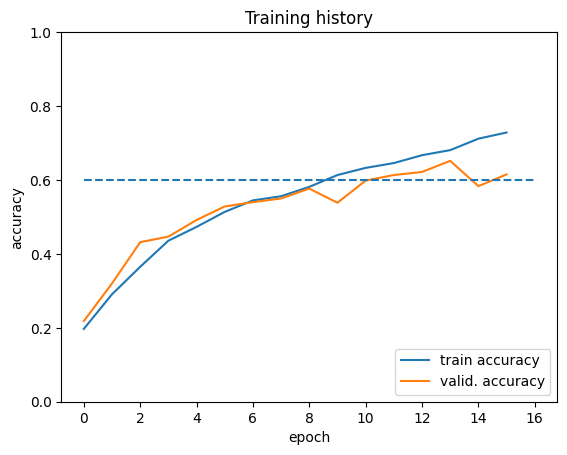


Accuracy of the trained model: 0.6150


In [ ]:
model2.compile(optimizer = 'adam',
              loss = losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics = ['accuracy'])

early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5)

history2 = model2.fit(X_trn, y_trn,
                    epochs = 16,
                    batch_size = 10,
                    callbacks = [early_stopping],
                    validation_data = (X_val, y_val)
                   )
eval_show(model2, history2.history, X_tst, y_tst)

This small model appears to be surprisingly good (relatively) in terms of accuracy.
Also, the plots for the accuracy on the training data and the validation one are closer to each other which doesn't seem usual. However, it means the model is not overfitted.

#### Model 3: a larger variant

Here, we change the base model more significantly: one extra convolutional layer added, the layer order is changed, sizes are increased.

In [ ]:
# Model 3 (extended version of the initial model)
model3 = models.Sequential([
  layers.Conv2D(64, (5, 5), activation='relu', input_shape=(32, 32, 3)), # 32 -> 64, 3 -> 5
  layers.Conv2D(64, (3, 3), activation='relu'),
  layers.MaxPooling2D((2, 2)),
  layers.Conv2D(128, (3, 3), activation='relu'),  # (changed: 64 -> 128)
  layers.Conv2D(256, (3, 3), strides = (2, 2), activation='relu'),  # (added)
  layers.MaxPooling2D((2, 2)),                    # (added)
  layers.Flatten(),
  layers.Dense(256, activation='relu'),      # 128 -> 256
  layers.Dense(128, activation='relu'),      # 64 ->128
  layers.Dense(n_classes)
])
model3.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 28, 28, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 13, 13, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 5, 5, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 707,402 (2.70 MB)

 Trainable params: 707,402 (2.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 32s 98ms/step - accuracy: 0.2167 - loss: 2.0452 - val_accuracy: 0.2833 - val_loss: 1.8965
Epoch 2/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.3373 - loss: 1.7860 - val_accuracy: 0.3633 - val_loss: 1.6815
Epoch 3/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 93ms/step - accuracy: 0.3900 - loss: 1.6652 - val_accuracy: 0.4783 - val_loss: 1.5183
Epoch 4/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 95ms/step - accuracy: 0.4537 - loss: 1.5241 - val_accuracy: 0.4883 - val_loss: 1.4625
Epoch 5/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.5103 - loss: 1.3835 - val_accuracy: 0.4633 - val_loss: 1.5143
Epoch 6/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 29s 97ms/step - accuracy: 0.5700 - loss: 1.2605 - val_accuracy: 0.4950 - val_loss: 1.4274
Epoch 7/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 41s 97ms/step - accuracy: 0.6337 - loss: 1.0685 - val_accuracy: 0.4933 - val_loss: 1.5271
Epoch 8/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 99ms/step - accuracy: 0.6880 - loss: 0.9088 - 

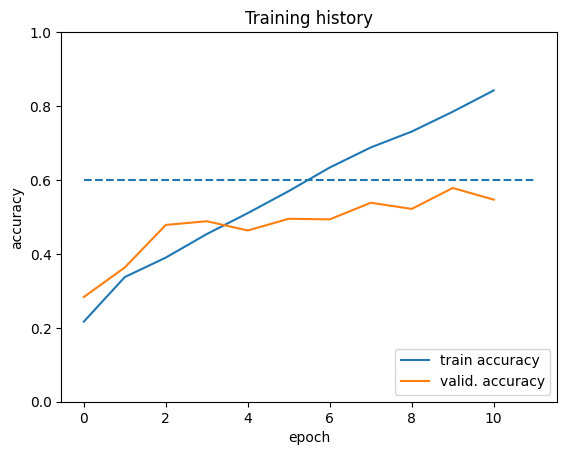


Accuracy of the trained model: 0.5467


In [ ]:
model3.compile(optimizer = 'adam',
              loss = losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics = ['accuracy'])

early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5)

history3 = model3.fit(X_trn, y_trn,
                    epochs = 16,
                    batch_size = 10,
                    callbacks = [early_stopping],
                    validation_data = (X_val, y_val)
                   )
eval_show(model3, history3.history, X_tst, y_tst)

However, large number of parameters doesn't affect positively the performance. It's worse than the previous models had.

#### Model 4: AlexNet-like

The _AlexNet_ model was taken as a start point. The number of layers and their sizes had to be reduced: the initial model expected images of much higher resolution and its convolutional and pooling layers would shrink our images to zero size. Also, the reduction was needed in view of computational limitations.

This is the largest model among the tried ones.

In [ ]:
model4 = models.Sequential([
    layers.Conv2D(64, (5, 5), padding = 'same', strides = (2, 2), activation = 'relu', input_shape = (32, 32, 3)),
    layers.MaxPooling2D((3, 3), strides = (1, 1)),
    layers.Conv2D(128, (3, 3), padding = 'same', strides = (2, 2), activation = 'relu'),
    layers.MaxPooling2D((2, 2), strides = (1, 1)),
    layers.Conv2D(256, (3, 3), padding = 'same', activation = 'relu'),
    layers.Conv2D(256, (3, 3), padding = 'same', activation = 'relu'),
    #layers.Conv2D(128, (3, 3), padding = 'same', activation = 'relu'),
    layers.MaxPooling2D((3, 3), strides = (2, 2)),
    layers.Flatten(),
    layers.Dense(512, activation = 'relu'),
    layers.Dropout(0.5),
    #layers.Dense(256, activation = 'relu'),
    #layers.Dropout(0.5),
    layers.Dense(n_classes)
])
model4.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │         4,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 6, 6, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 6, 6, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,493,898 (5.70 MB)

 Trainable params: 1,493,898 (5.70 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 30s 94ms/step - accuracy: 0.1857 - loss: 2.0868 - val_accuracy: 0.2533 - val_loss: 1.9870
Epoch 2/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.2743 - loss: 1.8956 - val_accuracy: 0.2717 - val_loss: 1.8264
Epoch 3/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 94ms/step - accuracy: 0.3373 - loss: 1.7702 - val_accuracy: 0.3967 - val_loss: 1.6408
Epoch 4/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 32s 106ms/step - accuracy: 0.3843 - loss: 1.6680 - val_accuracy: 0.4500 - val_loss: 1.6248
Epoch 5/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 37s 94ms/step - accuracy: 0.4357 - loss: 1.5643 - val_accuracy: 0.5000 - val_loss: 1.4456
Epoch 6/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.4840 - loss: 1.4650 - val_accuracy: 0.4833 - val_loss: 1.4476
Epoch 7/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 28s 93ms/step - accuracy: 0.5197 - loss: 1.3730 - val_accuracy: 0.4733 - val_loss: 1.4210
Epoch 8/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 40s 91ms/step - accuracy: 0.5780 - loss: 1.2533 -

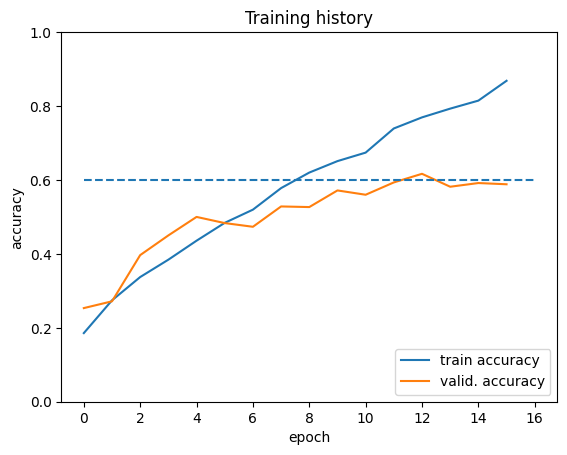


Accuracy of the trained model: 0.5883


In [ ]:
model4.compile(optimizer = 'adam',
              loss = losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics = ['accuracy'])

early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5)

history4 = model4.fit(X_trn, y_trn,
                    epochs = 16,
                    batch_size = 10,
                    callbacks = [early_stopping],
                    validation_data = (X_val, y_val)
                   )
eval_show(model4, history4.history, X_tst, y_tst)

Despite the model size, it doesn't perform any better than others.

#### Model 5: LeNet-5

This model implements the _LeNet-5_ architecture.

In [ ]:
model5 = models.Sequential([
      layers.Conv2D( 6, (5, 5), strides=(1,1), activation='relu', input_shape = (32, 32, 3)),
      layers.MaxPool2D((2, 2)),
      layers.Conv2D(16, (5, 5), strides=(1,1), activation='relu'),
      layers.MaxPool2D((2, 2)),
      layers.Flatten(),
      layers.Dense(120, activation='relu'),
      layers.Dense(84, activation='relu'),
      layers.Dense(n_classes)
      ])
model5.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 6)      │           456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 10, 10, 16)     │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 5, 5, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 120)            │        48,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,006 (242.21 KB)

 Trainable params: 62,006 (242.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.2850 - loss: 1.9255 - val_accuracy: 0.3733 - val_loss: 1.7103
Epoch 2/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.4340 - loss: 1.5772 - val_accuracy: 0.4133 - val_loss: 1.6144
Epoch 3/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.5040 - loss: 1.4358 - val_accuracy: 0.4133 - val_loss: 1.5836
Epoch 4/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5670 - loss: 1.2664 - val_accuracy: 0.4800 - val_loss: 1.4232
Epoch 5/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 9s 31ms/step - accuracy: 0.6347 - loss: 1.0988 - val_accuracy: 0.5000 - val_loss: 1.4491
Epoch 6/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.6667 - loss: 0.9801 - val_accuracy: 0.5300 - val_loss: 1.4263
Epoch 7/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.7167 - loss: 0.8481 - val_accuracy: 0.5317 - val_loss: 1.5054
Epoch 8/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7650 - loss: 0.7214 - val_accu

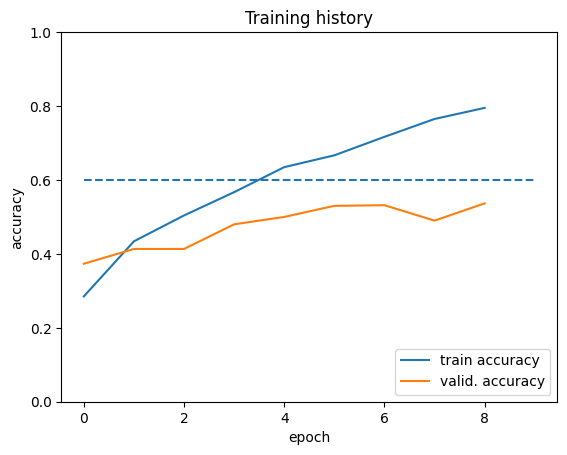


Accuracy of the trained model: 0.5317


In [ ]:
model5.compile(optimizer = 'adam',
              loss = losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics = ['accuracy'])

early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5)

history5 = model5.fit(X_trn, y_trn,
                    epochs = 16,
                    batch_size = 10,
                    callbacks = [early_stopping],
                    validation_data = (X_val, y_val)
                   )
eval_show(model5, history5.history, X_tst, y_tst)

#### Model 6: model 1 improved

We change model 1 in a different way than in case of models 2 and 3. (This architecture was used in an exercise of _Foundations of Machine Learning_ course.)

In [ ]:
model6 = models.Sequential([
  layers.Conv2D(32, (3, 3), padding = 'same', activation='relu', input_shape=(32, 32, 3)),
  layers.Conv2D(32, (3, 3), padding = 'same', activation='relu'),
  layers.MaxPooling2D((2, 2), strides = (2, 2)),
  layers.Dropout(0.25),
  layers.Conv2D(64, (3, 3), padding = 'same', activation='relu'),
  layers.Conv2D(64, (3, 3), padding = 'same', activation='relu'),
  layers.MaxPooling2D((2, 2), strides = (2, 2)),
  layers.Dropout(0.25),
  layers.Flatten(),
  layers.Dense(64, activation='relu'),
  layers.Dense(n_classes)
])
model6.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_19 (Conv2D)              │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_20 (Conv2D)              │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_21 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 64)             │       262,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,426 (1.25 MB)

 Trainable params: 328,426 (1.25 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 64ms/step - accuracy: 0.2477 - loss: 1.9892 - val_accuracy: 0.3200 - val_loss: 1.7840
Epoch 2/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 19s 63ms/step - accuracy: 0.4110 - loss: 1.6556 - val_accuracy: 0.4183 - val_loss: 1.6616
Epoch 3/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 21s 69ms/step - accuracy: 0.4990 - loss: 1.4541 - val_accuracy: 0.4650 - val_loss: 1.5203
Epoch 4/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.5833 - loss: 1.2373 - val_accuracy: 0.4933 - val_loss: 1.5023
Epoch 5/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 27s 88ms/step - accuracy: 0.6557 - loss: 1.0379 - val_accuracy: 0.5450 - val_loss: 1.3416
Epoch 6/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 78ms/step - accuracy: 0.6887 - loss: 0.9083 - val_accuracy: 0.5400 - val_loss: 1.5028
Epoch 7/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 42s 81ms/step - accuracy: 0.7590 - loss: 0.7385 - val_accuracy: 0.5750 - val_loss: 1.4561
Epoch 8/16
300/300 ━━━━━━━━━━━━━━━━━━━━ 24s 79ms/step - accuracy: 0.7893 - loss: 0.6250 - 

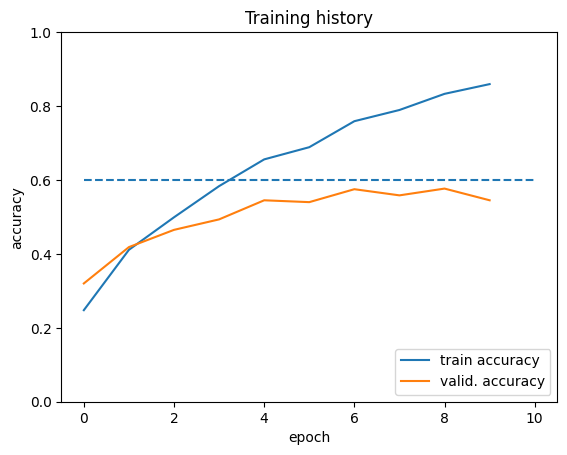


Accuracy of the trained model: 0.5917


In [ ]:
model6.compile(optimizer = 'adam',
              loss = losses.SparseCategoricalCrossentropy(from_logits = True),
              metrics = ['accuracy'])

early_stopping = callbacks.EarlyStopping(monitor = 'val_loss', patience = 5)

history6 = model6.fit(X_trn, y_trn,
                    epochs = 16,
                    batch_size = 10,
                    callbacks = [early_stopping],
                    validation_data = (X_val, y_val)
                   )
eval_show(model6, history6.history, X_tst, y_tst)

This model is also not that good on these data.

#### Summary

In the table below, the results are gathered.
Here, there are the numbers of different layers and the total numbers of learnable parameters in the models together with their test accuracy scores.

|No.| conv. | pool. | dense | param-s |   accur.|
|:-:|:-----:|:-----:|:-----:| ------:|:-----|
| 1 | 3 | 2 | 2 | 226794 | 0.5767 |
| 2 | 3 | 3 | 2 |  42218 | 0.6150 |
| 3 | 4 | 2 | 2 | 707402 | 0.5467 |
| 4 | 4 | 3 | 1 |1493898 | 0.5883 |
| 5 | 2 | 2 | 2 |  62006 | 0.5317 |
| 6 | 4 | 2 | 1 | 328426 | 0.5917 |

It is seen that model size doesn't correlate with accuracy.

### Hyperparameters

We try different combinations of parameters for **models 2 and 6** because they are relatively small, and hence multiple training runs should be feasible, and because they have shown the best performance among models 1-6 in the above settings.

We'll use the following values:

* activation : ReLU, sigmoid, tanh,
              
* optimizer : Adam, RMSprop, (SGD)
              
* learning rate : (0.0001), 0.0002, 0.001, (0.01)
              
* batch size : (10), 20, 100,
              
* epochs : 8, (16), 24

In parenthesis, partially tested values are indicated. Some of them were used in above calculations. Some others were dismissed shortly after the beginning, because they didn't provide any satisfactory results.


In [ ]:
param_grid = {'activation' : ['relu', 'sigmoid', 'tanh'],
              'optimizer' : ['adam', 'rmsprop'],
              'learning_rate' : [0.0002, 0.001],
              'batch_size' : [20, 100],
              'epochs' : [8, 24]
             }

# Create a list of all combinations
param_list = list(itertools.product(
    param_grid["activation"],
    param_grid["optimizer"],
    param_grid["learning_rate"],
    param_grid["batch_size"],
    param_grid["epochs"]
))

# Shuffle to try the combinations in random order
random.shuffle(param_list)

In [ ]:
# Saving result of each model into a csv file
def log_result(params, score1, score2, filepath = RESULTS_PATH):
    file_exists = os.path.isfile(filepath)
    with open(filepath, "a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(["activation", "optimizer", "learn_rate", "batch", "epochs", "accuracy1", "accuracy6"])
        writer.writerow(list(params) + [score1, score2])

# Checking if the combination is tried already
def already_done(params, filepath = RESULTS_PATH):
    if not os.path.isfile(filepath):
        return False
    with open(filepath, "r") as f:
        for line in f:
            if all(str(p) in line for p in params):
                return True
    return False

In [ ]:
# Get optimizer according to a string "label"
def get_opt(optimizer, learning_rate):
    if optimizer == 'adam':
        opt = optimizers.Adam(learning_rate = learning_rate)
    elif optimizer == 'sgd':
        opt = optimizers.SGD(learning_rate = learning_rate, momentum = 0.9)
    elif optimizer == 'rmsprop':
        opt = optimizers.RMSprop(learning_rate = learning_rate, rho = 0.9)
    else:
        raise ValueError("Invalid optimizer name")
    return opt

We'll use model builders to make definition and compilation of models with different hyperparameters easier.

In [ ]:
# Model 1 (will be used in the end for another data sample)

def build_model1(activation, optimizer, learning_rate):
    # define the model architecture
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), activation=activation),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation=activation),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation=activation),
        layers.Flatten(),
        layers.Dense(64, activation=activation),
        layers.Dense(32, activation=activation),
        layers.Dense(n_classes)
    ])

    # compile the model
    opt = get_opt(optimizer, learning_rate)

    model.compile(optimizer = opt,
                  loss = losses.SparseCategoricalCrossentropy(from_logits = True),
                  metrics = ['accuracy'])

    return model

In [ ]:
# Model 2

def build_model2(activation, optimizer, learning_rate):
    # define the model architecture
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(16, (5, 5), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(96, (3, 3), activation='relu'),
        layers.GlobalAveragePooling2D(),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(n_classes)
    ])

    # compile the model
    opt = get_opt(optimizer, learning_rate)

    model.compile(optimizer = opt,
                  loss = losses.SparseCategoricalCrossentropy(from_logits = True),
                  metrics = ['accuracy'])

    return model

In [ ]:
# Model 6

def build_model6(activation, optimizer, learning_rate):
    # define the model architecture
    model = models.Sequential([
        layers.Input(shape=(32, 32, 3)),
        layers.Conv2D(32, (3, 3), padding = 'same', activation=activation),
        layers.Conv2D(32, (3, 3), padding = 'same', activation=activation),
        layers.MaxPooling2D((2, 2), strides = (2, 2)),
        layers.Dropout(0.25),
        layers.Conv2D(64, (3, 3), padding = 'same', activation=activation),
        layers.Conv2D(64, (3, 3), padding = 'same', activation=activation),
        layers.MaxPooling2D((2, 2), strides = (2, 2)),
        layers.Dropout(0.25),
        layers.Flatten(),
        layers.Dense(64, activation=activation),
        layers.Dense(n_classes)
    ])

    # compile the model
    opt = get_opt(optimizer, learning_rate)

    model.compile(optimizer = opt,
                  loss = losses.SparseCategoricalCrossentropy(from_logits = True),
                  metrics = ['accuracy'])

    return model

For each combination of parameters, we will collect the maximum validation accuracy and the epoch which yielded it -- for both models 2 and 6.

In [ ]:
# dataframe for collecting results

accs = pd.DataFrame(columns = ['activation', 'optimizer', 'learning_rate', 'batch_size', 'epochs', 'm2_accuracy', 'm2_epoch', 'm6_accuracy', 'm6_epoch'])

#### Iteration through the parameters

In [ ]:


for params in param_list:
    a, o, lr, bs, e = params

    if already_done(params):
        print("Already done:", params)
        continue

    print(f"\nActivation: {a}; optimizer: {o}; learning rate: {lr}; batch size: {bs}; epochs: {e}")

    try:
        model2 = build_model2(a, o, lr)
        early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )
        print("Model 2")
        history2 = model2.fit(X_trn, y_trn,
                              epochs = e,
                              batch_size = bs,
                              callbacks = [early_stopping],
                              validation_data = (X_val, y_val)
                             )
        #test_acc2 = model2.evaluate(X_tst, y_tst, verbose = False)
        best_val_acc2 = float(np.round(max(history2.history["val_accuracy"]), 4))
        best_epoch2 = int(np.argmax(history2.history["val_accuracy"]))

        model6 = build_model6(a, o, lr)
        early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )
        print("Model 6")
        history6 = model6.fit(X_trn, y_trn,
                              epochs = e,
                              batch_size = bs,
                              callbacks = [early_stopping],
                              validation_data = (X_val, y_val)
                             )
        #test_acc6 = model6.evaluate(X_tst, y_tst, verbose = False)
        best_val_acc6 = float(np.round(max(history6.history["val_accuracy"]), 4))
        best_epoch6 = int(np.argmax(history6.history["val_accuracy"]))

        log_result(params, (best_val_acc2, best_epoch2), (best_val_acc6, best_epoch6))
        accs.loc[len(accs)] = [a, o, lr, bs, e, best_val_acc2, best_epoch2, best_val_acc6, best_epoch6]
        if accs.shape[0] % 5 == 0:
            display(accs)

    except Exception as e:
        print("Interruption:", e)
        continue


Activation: tanh; optimizer: adam; learning rate: 0.001; batch size: 100; epochs: 8
Model 2
Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 152ms/step - accuracy: 0.1500 - loss: 2.2474 - val_accuracy: 0.2033 - val_loss: 2.1592
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.2353 - loss: 2.0482 - val_accuracy: 0.2000 - val_loss: 2.0159
Epoch 3/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 80ms/step - accuracy: 0.2877 - loss: 1.9284 - val_accuracy: 0.2933 - val_loss: 1.9148
Epoch 4/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3157 - loss: 1.8326 - val_accuracy: 0.3083 - val_loss: 1.8331
Epoch 5/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.3513 - loss: 1.7668 - val_accuracy: 0.3717 - val_loss: 1.7593
Epoch 6/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 143ms/step - accuracy: 0.4130 - loss: 1.6584 - val_accuracy: 0.3983 - val_loss: 1.7118
Epoch 7/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 99ms/step - accuracy: 0.4490 - loss: 1.5794 - val_accuracy: 0.3967 - val_loss: 1.5929
Epoch 8/8
30/30 ━━━━━━━

,activation,optimizer,learning_rate,batch_size,epochs,m2_accuracy,m2_epoch,m6_accuracy,m6_epoch
0,relu,adam,0.0010,20,24,0.5800,23,0.6033,10
1,tanh,sgd,0.0010,100,8,0.1000,6,0.2667,7
2,tanh,adam,0.0002,20,24,0.4967,23,0.6383,14
3,relu,sgd,0.0002,100,24,0.1000,0,0.1067,10
4,sigmoid,adam,0.0002,100,8,0.3200,7,0.1000,0
5,tanh,adam,0.0010,100,8,0.4350,7,0.5950,7
6,sigmoid,rmsprop,0.0002,20,8,0.3683,7,0.1000,0
7,tanh,rmsprop,0.0010,100,8,0.3950,7,0.5700,7
8,relu,rmsprop,0.0002,100,24,0.3800,22,0.5483,22
9,tanh,adam,0.0010,20,24,0.5467,15,0.6517,10



Activation: sigmoid; optimizer: rmsprop; learning rate: 0.0002; batch size: 100; epochs: 8
Model 2
Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 88ms/step - accuracy: 0.1560 - loss: 2.2864 - val_accuracy: 0.1867 - val_loss: 2.2691
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.1820 - loss: 2.2362 - val_accuracy: 0.1867 - val_loss: 2.2172
Epoch 3/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.1907 - loss: 2.1731 - val_accuracy: 0.1917 - val_loss: 2.1716
Epoch 4/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 118ms/step - accuracy: 0.1943 - loss: 2.1289 - val_accuracy: 0.2033 - val_loss: 2.1395
Epoch 5/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 117ms/step - accuracy: 0.2140 - loss: 2.0971 - val_accuracy: 0.2350 - val_loss: 2.1148
Epoch 6/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 81ms/step - accuracy: 0.2237 - loss: 2.0740 - val_accuracy: 0.2300 - val_loss: 2.0937
Epoch 7/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 80ms/step - accuracy: 0.2247 - loss: 2.0488 - val_accuracy: 0.1783 - val_loss: 2.0769
Epoch 8/8
30/30 

,activation,optimizer,learning_rate,batch_size,epochs,m2_accuracy,m2_epoch,m6_accuracy,m6_epoch
0,relu,adam,0.0010,20,24,0.5800,23,0.6033,10
1,tanh,sgd,0.0010,100,8,0.1000,6,0.2667,7
2,tanh,adam,0.0002,20,24,0.4967,23,0.6383,14
3,relu,sgd,0.0002,100,24,0.1000,0,0.1067,10
4,sigmoid,adam,0.0002,100,8,0.3200,7,0.1000,0
5,tanh,adam,0.0010,100,8,0.4350,7,0.5950,7
6,sigmoid,rmsprop,0.0002,20,8,0.3683,7,0.1000,0
7,tanh,rmsprop,0.0010,100,8,0.3950,7,0.5700,7
8,relu,rmsprop,0.0002,100,24,0.3800,22,0.5483,22
9,tanh,adam,0.0010,20,24,0.5467,15,0.6517,10



Activation: tanh; optimizer: adam; learning rate: 0.001; batch size: 100; epochs: 24
Model 2
Epoch 1/24
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 135ms/step - accuracy: 0.1523 - loss: 2.2205 - val_accuracy: 0.1900 - val_loss: 2.0927
Epoch 2/24
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 86ms/step - accuracy: 0.2420 - loss: 2.0021 - val_accuracy: 0.2983 - val_loss: 1.9615
Epoch 3/24
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.3173 - loss: 1.8457 - val_accuracy: 0.3233 - val_loss: 1.8314
Epoch 4/24
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.3487 - loss: 1.7670 - val_accuracy: 0.3683 - val_loss: 1.7562
Epoch 5/24
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.3977 - loss: 1.6738 - val_accuracy: 0.4000 - val_loss: 1.6512
Epoch 6/24
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.4350 - loss: 1.6026 - val_accuracy: 0.4100 - val_loss: 1.6843
Epoch 7/24
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 87ms/step - accuracy: 0.4480 - loss: 1.5510 - val_accuracy: 0.4583 - val_loss: 1.5885
Epoch 8/24
30/3

...


Activation: sigmoid; optimizer: adam; learning rate: 0.0002; batch size: 20; epochs: 8
Model 2
Epoch 1/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 32ms/step - accuracy: 0.1827 - loss: 2.2054 - val_accuracy: 0.2100 - val_loss: 2.0625
Epoch 2/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.2680 - loss: 1.9564 - val_accuracy: 0.2767 - val_loss: 1.9467
Epoch 3/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3160 - loss: 1.8548 - val_accuracy: 0.2983 - val_loss: 1.8917
Epoch 4/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 7s 36ms/step - accuracy: 0.3313 - loss: 1.7998 - val_accuracy: 0.3133 - val_loss: 1.8275
Epoch 5/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3547 - loss: 1.7505 - val_accuracy: 0.3450 - val_loss: 1.7908
Epoch 6/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.3753 - loss: 1.7066 - val_accuracy: 0.3300 - val_loss: 1.7536
Epoch 7/8
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.3977 - loss: 1.6758 - val_accuracy: 0.3683 - val_loss: 1.7366
Epoch 8/

,activation,optimizer,learning_rate,batch_size,epochs,m2_accuracy,m2_epoch,m6_accuracy,m6_epoch
0,relu,adam,0.0010,20,24,0.5800,23,0.6033,10
1,tanh,sgd,0.0010,100,8,0.1000,6,0.2667,7
2,tanh,adam,0.0002,20,24,0.4967,23,0.6383,14
3,relu,sgd,0.0002,100,24,0.1000,0,0.1067,10
4,sigmoid,adam,0.0002,100,8,0.3200,7,0.1000,0
5,tanh,adam,0.0010,100,8,0.4350,7,0.5950,7
6,sigmoid,rmsprop,0.0002,20,8,0.3683,7,0.1000,0
7,tanh,rmsprop,0.0010,100,8,0.3950,7,0.5700,7
8,relu,rmsprop,0.0002,100,24,0.3800,22,0.5483,22
9,tanh,adam,0.0010,20,24,0.5467,15,0.6517,10



Activation: sigmoid; optimizer: adam; learning rate: 0.001; batch size: 100; epochs: 8
Model 2
Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 136ms/step - accuracy: 0.1693 - loss: 2.2227 - val_accuracy: 0.1617 - val_loss: 2.1479
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 91ms/step - accuracy: 0.1953 - loss: 2.0737 - val_accuracy: 0.1833 - val_loss: 2.0591
Epoch 3/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.2290 - loss: 1.9949 - val_accuracy: 0.2167 - val_loss: 2.0029
Epoch 4/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 96ms/step - accuracy: 0.2610 - loss: 1.9237 - val_accuracy: 0.2600 - val_loss: 1.9530
Epoch 5/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 97ms/step - accuracy: 0.3153 - loss: 1.8475 - val_accuracy: 0.3300 - val_loss: 1.8530
Epoch 6/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step - accuracy: 0.3450 - loss: 1.7806 - val_accuracy: 0.3300 - val_loss: 1.8110
Epoch 7/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step - accuracy: 0.3813 - loss: 1.6893 - val_accuracy: 0.3567 - val_loss: 1.7706
Epoch 8/8
30/30 ━━━━━

,activation,optimizer,learning_rate,batch_size,epochs,m2_accuracy,m2_epoch,m6_accuracy,m6_epoch
0,relu,adam,0.0010,20,24,0.5800,23,0.6033,10
1,tanh,sgd,0.0010,100,8,0.1000,6,0.2667,7
2,tanh,adam,0.0002,20,24,0.4967,23,0.6383,14
3,relu,sgd,0.0002,100,24,0.1000,0,0.1067,10
4,sigmoid,adam,0.0002,100,8,0.3200,7,0.1000,0
5,tanh,adam,0.0010,100,8,0.4350,7,0.5950,7
6,sigmoid,rmsprop,0.0002,20,8,0.3683,7,0.1000,0
7,tanh,rmsprop,0.0010,100,8,0.3950,7,0.5700,7
8,relu,rmsprop,0.0002,100,24,0.3800,22,0.5483,22
9,tanh,adam,0.0010,20,24,0.5467,15,0.6517,10



Activation: relu; optimizer: adam; learning rate: 0.001; batch size: 100; epochs: 8
Model 2
Epoch 1/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 7s 151ms/step - accuracy: 0.1577 - loss: 2.2129 - val_accuracy: 0.1650 - val_loss: 2.1133
Epoch 2/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.2257 - loss: 2.0122 - val_accuracy: 0.2083 - val_loss: 1.9912
Epoch 3/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.2587 - loss: 1.9304 - val_accuracy: 0.2350 - val_loss: 1.9408
Epoch 4/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 113ms/step - accuracy: 0.2860 - loss: 1.8768 - val_accuracy: 0.2733 - val_loss: 1.8766
Epoch 5/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 89ms/step - accuracy: 0.3327 - loss: 1.8000 - val_accuracy: 0.3017 - val_loss: 1.8352
Epoch 6/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.3643 - loss: 1.7670 - val_accuracy: 0.3767 - val_loss: 1.7509
Epoch 7/8
30/30 ━━━━━━━━━━━━━━━━━━━━ 3s 86ms/step - accuracy: 0.4093 - loss: 1.6655 - val_accuracy: 0.3867 - val_loss: 1.7137
Epoch 8/8
30/30 ━━━━━━━

#### Results

Here is the results. The beginning is absent due to technical interruptions (the whole table was stored in a csv-file).

In the last column of the table we have:

* `m2_accuracy` is the maximum validation accuracy of model 2 accross epochs,

* `m2_epoch` is the index of the epoch on which the maximum accuracy of model 2 was achieved,

* `m6_accuracy` is the maximum validation accuracy of model 6 accross epochs,

* `m6_epoch` is the index of the epoch on which the maximum accuracy of model 6 was achieved.

In [ ]:
display(accs)

,activation,optimizer,learning_rate,batch_size,epochs,m2_accuracy,m2_epoch,m6_accuracy,m6_epoch
0,relu,adam,0.0010,20,24,0.5800,23,0.6033,10
1,tanh,sgd,0.0010,100,8,0.1000,6,0.2667,7
2,tanh,adam,0.0002,20,24,0.4967,23,0.6383,14
3,relu,sgd,0.0002,100,24,0.1000,0,0.1067,10
4,sigmoid,adam,0.0002,100,8,0.3200,7,0.1000,0
5,tanh,adam,0.0010,100,8,0.4350,7,0.5950,7
6,sigmoid,rmsprop,0.0002,20,8,0.3683,7,0.1000,0
7,tanh,rmsprop,0.0010,100,8,0.3950,7,0.5700,7
8,relu,rmsprop,0.0002,100,24,0.3800,22,0.5483,22
9,tanh,adam,0.0010,20,24,0.5467,15,0.6517,10


The best parameter combinations are:

* model 2: activation sigmoid, optimizer RMSprop, learning rate 0.001, batch size 20, epochs 24 $\to$ accuracy 0.5983;

* model 6: activation tanh, optimizer Adam, learning rate 0.001, batch size	20, epochs 24 $\to$ accuracy 0.6517.

#### Retraining on full dataset

Let's retrain both models with their best parameters on full data (but the same 10 classes) and evaluate their performance on the test set.

In [ ]:
# We still need excerpt the 10 classes

X_trn, y_trn = sample_images(X_train,
                      y_train,
                      sample_classes,
                      400
                     )
X_val, y_val = sample_images(X_valid,
                      y_valid,
                      sample_classes,
                      100
                     )
X_tst, y_tst = sample_images(X_test,
                      y_test,
                      sample_classes,
                      100
                     )
print(X_trn.shape)
print(y_trn.shape)
print(X_tst.shape)
print(y_tst.shape)

(4000, 32, 32, 3)
(4000,)
(1000, 32, 32, 3)
(1000,)


In [ ]:
# Check if data is already normalized or not
print(np.min(X_trn), np.max(X_trn))
print(np.min(X_val), np.max(X_val))
print(np.min(X_tst), np.max(X_tst))

0 255
0 255
0 255


In [ ]:
# Normalize pixel values to be between 0 and 1
X_trn, X_val, X_tst = X_trn / 255.0, X_val / 255.0, X_tst / 255.0

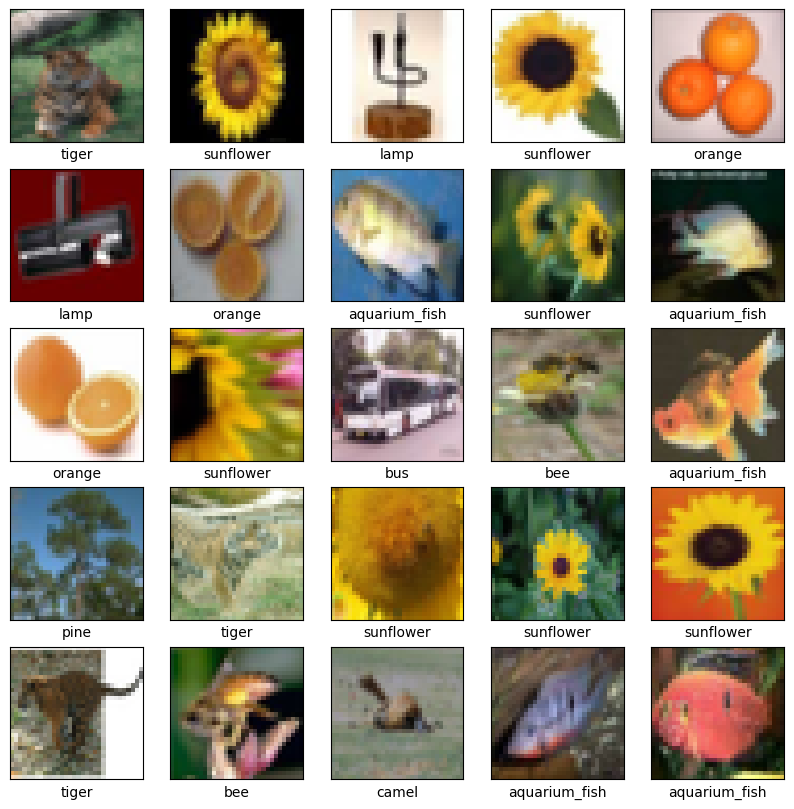

In [ ]:
# Show examples

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_trn[i])
    plt.xlabel(sample_classes[y_trn[i]])
plt.show()

In [ ]:
# Model 2

model2 = build_model2('sigmoid', 'rmsprop', 0.001)
early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )

history2 = model2.fit(X_trn, y_trn,
                      epochs = 50,      # add more epochs
                      batch_size = 20,
                      callbacks = [early_stopping],
                      validation_data = (X_val, y_val)
                     )


Epoch 1/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.2173 - loss: 2.0449 - val_accuracy: 0.2640 - val_loss: 1.9854
Epoch 2/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3273 - loss: 1.8256 - val_accuracy: 0.3540 - val_loss: 1.7355
Epoch 3/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.3988 - loss: 1.6668 - val_accuracy: 0.4630 - val_loss: 1.5431
Epoch 4/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.4403 - loss: 1.5558 - val_accuracy: 0.4760 - val_loss: 1.4711
Epoch 5/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.4723 - loss: 1.4802 - val_accuracy: 0.4820 - val_loss: 1.4090
Epoch 6/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5050 - loss: 1.3962 - val_accuracy: 0.5240 - val_loss: 1.3913
Epoch 7/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 9s 21ms/step - accuracy: 0.5228 - loss: 1.3312 - val_accuracy: 0.4320 - val_loss: 1.4599
Epoch 8/50
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 28ms/step - accuracy: 0.5500 - loss: 1.2914 - val_accu

InvalidArgumentError: Graph execution error:

Detected at node compile_loss/sparse_categorical_crossentropy/SparseSoftmaxCrossEntropyWithLogits/SparseSoftmaxCrossEntropyWithLogits defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>

  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance

  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start

  File "/usr/local/lib/python3.12/dist-packages/tornado/platform/asyncio.py", line 211, in start

  File "/usr/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/usr/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/usr/lib/python3.12/asyncio/events.py", line 88, in _run

  File "/usr/local/lib/python3.12/dist-packages/ipyker

In [ ]:
# Scores
best_val_acc2 = float(np.round(max(history2.history["val_accuracy"]), 4))
best_epoch2 = int(np.argmax(history2.history["val_accuracy"]))
_, test_acc2 = model2.evaluate(X_tst, y_tst, verbose = False)
print(f"Best validation accuracy: {best_val_acc2} at epoch {best_epoch2}")
print(f"Test accuracy: {test_acc2}")

Best validation accuracy: 0.678 at epoch 28
Test accuracy: 0.7099999785423279


For the model 2, we get better accuracy rate compared to the initial setting:
$$0.615 \to 0.71$$

In [ ]:
# Model 6

model6 = build_model6('tanh', 'adam', 0.001)
early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )

history6 = model6.fit(X_trn, y_trn,
                      epochs = 20,      # reduce epochs for shorter computation
                      batch_size = 20,
                      callbacks = [early_stopping],
                      validation_data = (X_val, y_val)
                     )
best_val_acc6 = float(np.round(max(history6.history["val_accuracy"]), 4))
best_epoch6 = int(np.argmax(history6.history["val_accuracy"]))
_, test_acc6 = model6.evaluate(X_tst, y_tst, verbose = False)
print(f"Best validation accuracy: {best_val_acc6} at epoch {best_epoch6}")
print(f"Test accuracy: {test_acc6}")

Epoch 1/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 29s 133ms/step - accuracy: 0.4218 - loss: 1.6626 - val_accuracy: 0.5310 - val_loss: 1.3908
Epoch 2/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 25s 127ms/step - accuracy: 0.5810 - loss: 1.2374 - val_accuracy: 0.5740 - val_loss: 1.2198
Epoch 3/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - accuracy: 0.6575 - loss: 1.0321 - val_accuracy: 0.6310 - val_loss: 1.1277
Epoch 4/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - accuracy: 0.7153 - loss: 0.8609 - val_accuracy: 0.6530 - val_loss: 1.0405
Epoch 5/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 126ms/step - accuracy: 0.7678 - loss: 0.7284 - val_accuracy: 0.6400 - val_loss: 1.0479
Epoch 6/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 27s 136ms/step - accuracy: 0.7915 - loss: 0.6284 - val_accuracy: 0.6780 - val_loss: 0.9852
Epoch 7/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 41s 137ms/step - accuracy: 0.8395 - loss: 0.5032 - val_accuracy: 0.6930 - val_loss: 0.9270
Epoch 8/20
200/200 ━━━━━━━━━━━━━━━━━━━━ 26s 131ms/step - accuracy: 0.8777 - loss: 0

The increase of accuracy for model 6 architecture is:
$$0.5917 \to 0.6517 \to 0.698$$
(from the initial model through the model with the best hyperparameters).

## Repeating experiments with other data

We take the same models 2 and 6 and give another chance to model 1 -- in order to  train them on another sample of the CIFAR-100 dataset.

This time we choose 8 classes, 250 examples per class (in the training part) to make computations a bit faster.
Also, the classes are chosen so that their objects are expectedly well distinguashable from each other. Let's see whether such a classification task will be indeed easier to the models.

#### New data sample

In [ ]:
# new classes
sample_classes = [
    "bicycle",
    "bottle",
    "butterfly",
    "clock",
    "cloud",
    "mushroom",
    "ray",
    "worm"
  ]

sample_cls_name2idx = {sample_classes[i]: i for i in range(len(sample_classes))}
n_classes = len(sample_classes)

# downsampled dataset
X_trn, y_trn = sample_images(X_train,
                      y_train,
                      sample_classes,
                      250
                     )
X_tst, y_tst = sample_images(X_test,
                      y_test,
                      sample_classes,
                      50
                     )
print(X_trn.shape)
print(y_trn.shape)
print(X_tst.shape)
print(y_tst.shape)

(2000, 32, 32, 3)
(2000,)
(400, 32, 32, 3)
(400,)


In [ ]:
X_val, y_val = sample_images(X_valid,
                      y_valid,
                      sample_classes,
                      50
                     )
print(X_val.shape)
print(y_val.shape)

(400, 32, 32, 3)
(400,)


In [ ]:
#  Check if data is normalized
print(np.min(X_trn), np.max(X_trn))
print(np.min(X_val), np.max(X_val))
print(np.min(X_tst), np.max(X_tst))

0 255
0 255
0 255


In [ ]:
# Normalize pixel values to be between 0 and 1
X_trn, X_val, X_tst = X_trn / 255.0, X_val / 255.0, X_tst / 255.0

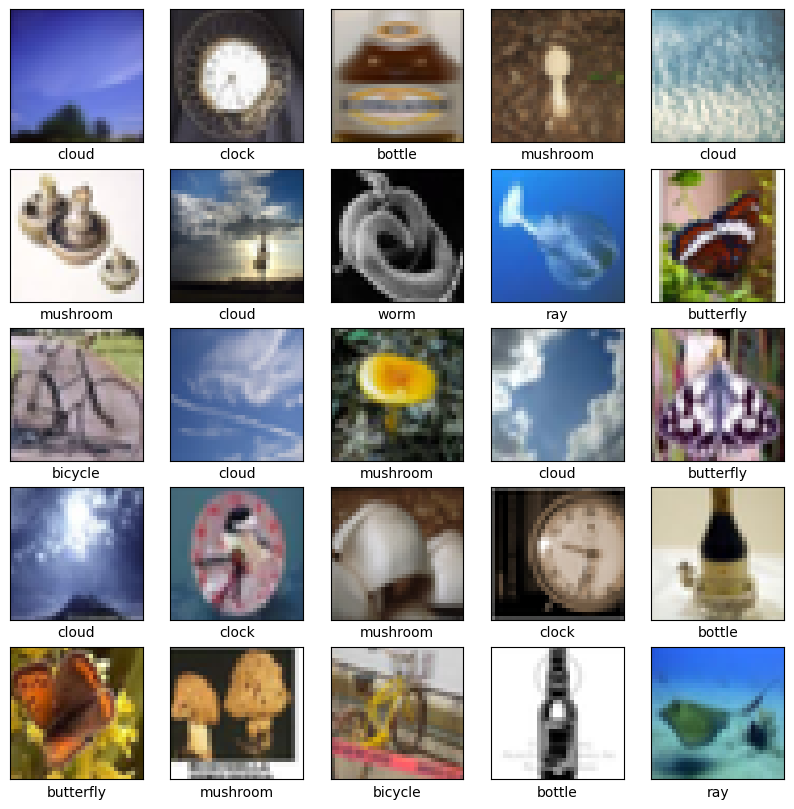

In [ ]:
# Show examples

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_trn[i])
    plt.xlabel(sample_classes[y_trn[i]])
plt.show()

#### Architecture choice

In [ ]:
# Model 1

model1 = build_model1('relu', 'adam', 0.001)
early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )

history1 = model1.fit(X_trn, y_trn,
                      epochs = 16,
                      batch_size = 10,
                      callbacks = [early_stopping],
                      validation_data = (X_val, y_val)
                     )
best_val_acc1 = float(np.round(max(history1.history["val_accuracy"]), 4))
best_epoch1 = int(np.argmax(history1.history["val_accuracy"]))
last_val_acc1 = float(np.round(history1.history["val_accuracy"][-1], 4))
print(f"Best validation accuracy: {best_val_acc1} at epoch {best_epoch1}")
print(f"Last validation accuracy: {last_val_acc1}")

Epoch 1/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.2170 - loss: 1.9446 - val_accuracy: 0.3275 - val_loss: 1.8266
Epoch 2/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.3435 - loss: 1.7008 - val_accuracy: 0.3900 - val_loss: 1.6349
Epoch 3/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - accuracy: 0.4110 - loss: 1.5829 - val_accuracy: 0.4375 - val_loss: 1.5570
Epoch 4/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 6s 30ms/step - accuracy: 0.4940 - loss: 1.4543 - val_accuracy: 0.4500 - val_loss: 1.5471
Epoch 5/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.5415 - loss: 1.3072 - val_accuracy: 0.5300 - val_loss: 1.3477
Epoch 6/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.6000 - loss: 1.1685 - val_accuracy: 0.5550 - val_loss: 1.3866
Epoch 7/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - accuracy: 0.6030 - loss: 1.0950 - val_accuracy: 0.5900 - val_loss: 1.2142
Epoch 8/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.6505 - loss: 0.9915 - val_accu

In [ ]:
# Model 2

model2 = build_model2('relu', 'adam', 0.001)
early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )

history2 = model2.fit(X_trn, y_trn,
                      epochs = 16,
                      batch_size = 10,
                      callbacks = [early_stopping],
                      validation_data = (X_val, y_val)
                     )
best_val_acc2 = float(np.round(max(history2.history["val_accuracy"]), 4))
best_epoch2 = int(np.argmax(history2.history["val_accuracy"]))
last_val_acc2 = float(np.round(history2.history["val_accuracy"][-1], 4))
print(f"Best validation accuracy: {best_val_acc2} at epoch {best_epoch2}")
print(f"Last validation accuracy: {last_val_acc2}")

Epoch 1/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.1915 - loss: 1.9927 - val_accuracy: 0.2775 - val_loss: 1.8543
Epoch 2/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.3185 - loss: 1.7622 - val_accuracy: 0.3425 - val_loss: 1.7681
Epoch 3/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.3575 - loss: 1.6718 - val_accuracy: 0.3800 - val_loss: 1.6763
Epoch 4/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - accuracy: 0.4050 - loss: 1.5823 - val_accuracy: 0.4625 - val_loss: 1.6093
Epoch 5/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4550 - loss: 1.4790 - val_accuracy: 0.4175 - val_loss: 1.5737
Epoch 6/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.4775 - loss: 1.4298 - val_accuracy: 0.4100 - val_loss: 1.6586
Epoch 7/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 0.5110 - loss: 1.3472 - val_accuracy: 0.4525 - val_loss: 1.5457
Epoch 8/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 4s 22ms/step - accuracy: 0.5300 - loss: 1.3042 - val_accu

In [ ]:
# Model 6

model6 = build_model6('relu', 'adam', 0.001)
early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )

history6 = model6.fit(X_trn, y_trn,
                      epochs = 16,
                      batch_size = 10,
                      callbacks = [early_stopping],
                      validation_data = (X_val, y_val)
                     )
best_val_acc6 = float(np.round(max(history6.history["val_accuracy"]), 4))
best_epoch6 = int(np.argmax(history6.history["val_accuracy"]))
last_val_acc6 = float(np.round(history6.history["val_accuracy"][-1], 4))
print(f"Best validation accuracy: {best_val_acc6} at epoch {best_epoch6}")
print(f"Last validation accuracy: {last_val_acc6}")

Epoch 1/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 18s 77ms/step - accuracy: 0.2405 - loss: 1.9092 - val_accuracy: 0.3750 - val_loss: 1.6985
Epoch 2/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 68ms/step - accuracy: 0.4200 - loss: 1.5501 - val_accuracy: 0.4975 - val_loss: 1.4850
Epoch 3/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.5160 - loss: 1.3382 - val_accuracy: 0.5025 - val_loss: 1.4376
Epoch 4/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 19s 61ms/step - accuracy: 0.5785 - loss: 1.2063 - val_accuracy: 0.5400 - val_loss: 1.2776
Epoch 5/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.6165 - loss: 1.0799 - val_accuracy: 0.5800 - val_loss: 1.1892
Epoch 6/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 14s 68ms/step - accuracy: 0.6710 - loss: 0.9434 - val_accuracy: 0.6000 - val_loss: 1.1757
Epoch 7/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 20s 66ms/step - accuracy: 0.7205 - loss: 0.8290 - val_accuracy: 0.6150 - val_loss: 1.1690
Epoch 8/16
200/200 ━━━━━━━━━━━━━━━━━━━━ 13s 63ms/step - accuracy: 0.7490 - loss: 0.7180 - 

Let's proceed with **models 1 and 6**, because in this case they show substantially better performance than model 2.

In [ ]:
RESULTS_PATH_R = "/content/drive/MyDrive/cnn_project_results_r.csv"

#### Parameter choice

The following processing is the same as earlier except for another data sample and a reduced choice of parameters:
we won't consider

* learning rates other than 0.001, because this value looked optimal in the previous computations;

* numbers of epochs other than 24, because we have the early-stop option for the cases when fewer epochs are sufficient and greater values may require too long computations.

In [ ]:
param_grid = {'activation' : ['relu', 'sigmoid', 'tanh'],
              'optimizer' : ['adam', 'rmsprop'],
              'learning_rate' : [0.001],
              'batch_size' : [20, 100],
              'epochs' : [24]
             }

# Create a list of all combinations
param_list = list(itertools.product(
    param_grid["activation"],
    param_grid["optimizer"],
    param_grid["learning_rate"],
    param_grid["batch_size"],
    param_grid["epochs"]
))

# Shuffle to try the combinations in random order
random.shuffle(param_list)

In [ ]:
# Collect results in the dataframe
accs_r = pd.DataFrame(columns = ['activation', 'optimizer', 'learning_rate', 'batch_size', 'epochs', 'm1_accuracy', 'm1_epoch', 'm6_accuracy', 'm6_epoch'])

#### Iteration through parameters

In [ ]:
for params in param_list:
    a, o, lr, bs, e = params

    if already_done(params, RESULTS_PATH_R):
        print("Already done:", params)
        continue

    print(f"\nActivation: {a}; optimizer: {o}; learning rate: {lr}; batch size: {bs}; epochs: {e}")

    try:
        model1 = build_model1(a, o, lr)
        early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )
        print("Model 1")
        history1 = model1.fit(X_trn, y_trn,
                              epochs = e,
                              batch_size = bs,
                              callbacks = [early_stopping],
                              validation_data = (X_val, y_val)
                             )
        #test_acc1 = model1.evaluate(X_tst, y_tst, verbose = False)
        best_val_acc1 = float(np.round(max(history1.history["val_accuracy"]), 4))
        best_epoch1 = int(np.argmax(history1.history["val_accuracy"]))

        model6 = build_model6(a, o, lr)
        early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )
        print("Model 6")
        history6 = model6.fit(X_trn, y_trn,
                              epochs = e,
                              batch_size = bs,
                              callbacks = [early_stopping],
                              validation_data = (X_val, y_val)
                             )
        #test_acc6 = model6.evaluate(X_tst, y_tst, verbose = False)
        best_val_acc6 = float(np.round(max(history6.history["val_accuracy"]), 4))
        best_epoch6 = int(np.argmax(history6.history["val_accuracy"]))

        log_result(params, (best_val_acc1, best_epoch1), (best_val_acc6, best_epoch6), RESULTS_PATH_R)
        accs_r.loc[len(accs_r)] = [a, o, lr, bs, e, best_val_acc1, best_epoch1, best_val_acc6, best_epoch6]
        if accs_r.shape[0] % 5 == 0:
            display(accs)

    except Exception as e:
        print("Interruption:", e)
        continue


Activation: tanh; optimizer: adam; learning rate: 0.001; batch size: 20; epochs: 24
Model 1
Epoch 1/24
100/100 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.3660 - loss: 1.6858 - val_accuracy: 0.4675 - val_loss: 1.4742
Epoch 2/24
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - accuracy: 0.5220 - loss: 1.3488 - val_accuracy: 0.5475 - val_loss: 1.3418
Epoch 3/24
100/100 ━━━━━━━━━━━━━━━━━━━━ 7s 57ms/step - accuracy: 0.5775 - loss: 1.2224 - val_accuracy: 0.5375 - val_loss: 1.3233
Epoch 4/24
100/100 ━━━━━━━━━━━━━━━━━━━━ 3s 33ms/step - accuracy: 0.6190 - loss: 1.1085 - val_accuracy: 0.5725 - val_loss: 1.2788
Epoch 5/24
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - accuracy: 0.6795 - loss: 0.9702 - val_accuracy: 0.5775 - val_loss: 1.1615
Epoch 6/24
100/100 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.7025 - loss: 0.8868 - val_accuracy: 0.6100 - val_loss: 1.1672
Epoch 7/24
100/100 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.7570 - loss: 0.7361 - val_accuracy: 0.6375 - val_loss: 1.0953
Epoc

,activation,optimizer,learning_rate,batch_size,epochs,m2_accuracy,m2_epoch,m6_accuracy,m6_epoch
0,relu,adam,0.0010,20,24,0.5800,23,0.6033,10
1,tanh,sgd,0.0010,100,8,0.1000,6,0.2667,7
2,tanh,adam,0.0002,20,24,0.4967,23,0.6383,14
3,relu,sgd,0.0002,100,24,0.1000,0,0.1067,10
4,sigmoid,adam,0.0002,100,8,0.3200,7,0.1000,0
5,tanh,adam,0.0010,100,8,0.4350,7,0.5950,7
6,sigmoid,rmsprop,0.0002,20,8,0.3683,7,0.1000,0
7,tanh,rmsprop,0.0010,100,8,0.3950,7,0.5700,7
8,relu,rmsprop,0.0002,100,24,0.3800,22,0.5483,22
9,tanh,adam,0.0010,20,24,0.5467,15,0.6517,10



Activation: tanh; optimizer: rmsprop; learning rate: 0.001; batch size: 100; epochs: 24
Model 1
Epoch 1/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 156ms/step - accuracy: 0.2505 - loss: 2.0261 - val_accuracy: 0.4350 - val_loss: 1.6905
Epoch 2/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 151ms/step - accuracy: 0.4035 - loss: 1.6435 - val_accuracy: 0.4775 - val_loss: 1.5768
Epoch 3/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 147ms/step - accuracy: 0.4770 - loss: 1.4799 - val_accuracy: 0.4425 - val_loss: 1.4870
Epoch 4/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 217ms/step - accuracy: 0.5245 - loss: 1.3852 - val_accuracy: 0.5150 - val_loss: 1.3695
Epoch 5/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 159ms/step - accuracy: 0.5580 - loss: 1.2817 - val_accuracy: 0.5550 - val_loss: 1.3047
Epoch 6/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 5s 142ms/step - accuracy: 0.6100 - loss: 1.1697 - val_accuracy: 0.5075 - val_loss: 1.4303
Epoch 7/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 227ms/step - accuracy: 0.6200 - loss: 1.1055 - val_accuracy: 0.6025 - val_loss: 1.2144
Epoch 8

,activation,optimizer,learning_rate,batch_size,epochs,m2_accuracy,m2_epoch,m6_accuracy,m6_epoch
0,relu,adam,0.0010,20,24,0.5800,23,0.6033,10
1,tanh,sgd,0.0010,100,8,0.1000,6,0.2667,7
2,tanh,adam,0.0002,20,24,0.4967,23,0.6383,14
3,relu,sgd,0.0002,100,24,0.1000,0,0.1067,10
4,sigmoid,adam,0.0002,100,8,0.3200,7,0.1000,0
5,tanh,adam,0.0010,100,8,0.4350,7,0.5950,7
6,sigmoid,rmsprop,0.0002,20,8,0.3683,7,0.1000,0
7,tanh,rmsprop,0.0010,100,8,0.3950,7,0.5700,7
8,relu,rmsprop,0.0002,100,24,0.3800,22,0.5483,22
9,tanh,adam,0.0010,20,24,0.5467,15,0.6517,10



Activation: relu; optimizer: rmsprop; learning rate: 0.001; batch size: 100; epochs: 24
Model 1
Epoch 1/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 138ms/step - accuracy: 0.1840 - loss: 2.0438 - val_accuracy: 0.2375 - val_loss: 1.9479
Epoch 2/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.2605 - loss: 1.8804 - val_accuracy: 0.2925 - val_loss: 1.8571
Epoch 3/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.3175 - loss: 1.8110 - val_accuracy: 0.3625 - val_loss: 1.7154
Epoch 4/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 159ms/step - accuracy: 0.3710 - loss: 1.6923 - val_accuracy: 0.2975 - val_loss: 1.9113
Epoch 5/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 214ms/step - accuracy: 0.4025 - loss: 1.6255 - val_accuracy: 0.2675 - val_loss: 2.1858
Epoch 6/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 127ms/step - accuracy: 0.4295 - loss: 1.5796 - val_accuracy: 0.3925 - val_loss: 1.5523
Epoch 7/24
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 125ms/step - accuracy: 0.4690 - loss: 1.5228 - val_accuracy: 0.4550 - val_loss: 1.4858
Epoch 8

### Results

The results of 12 training runs for 2 models are represented in the table below.
In the last column of the table we have:

* `m1_accuracy` is the maximum validation accuracy of model 1 accross epochs,

* `m1_epoch` is the index of the epoch on which the maximum accuracy of model 1 was achieved,

* `m6_accuracy` is the maximum validation accuracy of model 6 accross epochs,

* `m6_epoch` is the index of the epoch on which the maximum accuracy of model 6 was achieved.


In [ ]:
display(accs_r)

,activation,optimizer,learning_rate,batch_size,epochs,m1_accuracy,m1_epoch,m6_accuracy,m6_epoch
0,tanh,adam,0.001,20,24,0.6425,10,0.6700,7
1,sigmoid,rmsprop,0.001,100,24,0.1250,0,0.1250,0
2,relu,adam,0.001,100,24,0.6650,23,0.6400,14
3,relu,rmsprop,0.001,20,24,0.6475,14,0.6500,12
4,tanh,rmsprop,0.001,20,24,0.6200,5,0.6425,7
5,tanh,rmsprop,0.001,100,24,0.6275,15,0.6400,13
6,sigmoid,rmsprop,0.001,20,24,0.1250,0,0.1925,12
7,tanh,adam,0.001,100,24,0.6650,14,0.6575,17
8,sigmoid,adam,0.001,100,24,0.1250,0,0.3675,22
9,relu,adam,0.001,20,24,0.6500,15,0.6300,9


The best parameter combinations are:

* model 1: activation ReLU/tanh, optimizer Adam, batch size	100 $\to$ accuracy 0.665
(ReLU probably has greater potential, because the best accuracy was achieved on 23 and may increase further);

* model 6: ctivation tanh, optimizer Adam, batch size	20 (the same combination as in previous case) $\to$ accuracy 0.67.

#### Retraining on full dataset

Let's retrain the best models on the "full" dataset except we've removed all but 8 classes.

In [ ]:
X_trn, y_trn = sample_images(X_train,
                      y_train,
                      sample_classes,
                      400
                     )
X_val, y_val = sample_images(X_valid,
                      y_valid,
                      sample_classes,
                      100
                     )
X_tst, y_tst = sample_images(X_test,
                      y_test,
                      sample_classes,
                      100
                     )
print(X_trn.shape)
print(y_trn.shape)
print(X_val.shape)
print(y_tst.shape)

(3200, 32, 32, 3)
(3200,)
(800, 32, 32, 3)
(800,)


In [ ]:
# Check if data is already normalized or not
print(np.min(X_trn), np.max(X_trn))
print(np.min(X_val), np.max(X_val))
print(np.min(X_tst), np.max(X_tst))

0 255
0 255
0 255


In [ ]:
# Normalize pixel values to be between 0 and 1
X_trn, X_val, X_tst = X_trn / 255.0, X_val / 255.0, X_tst / 255.0

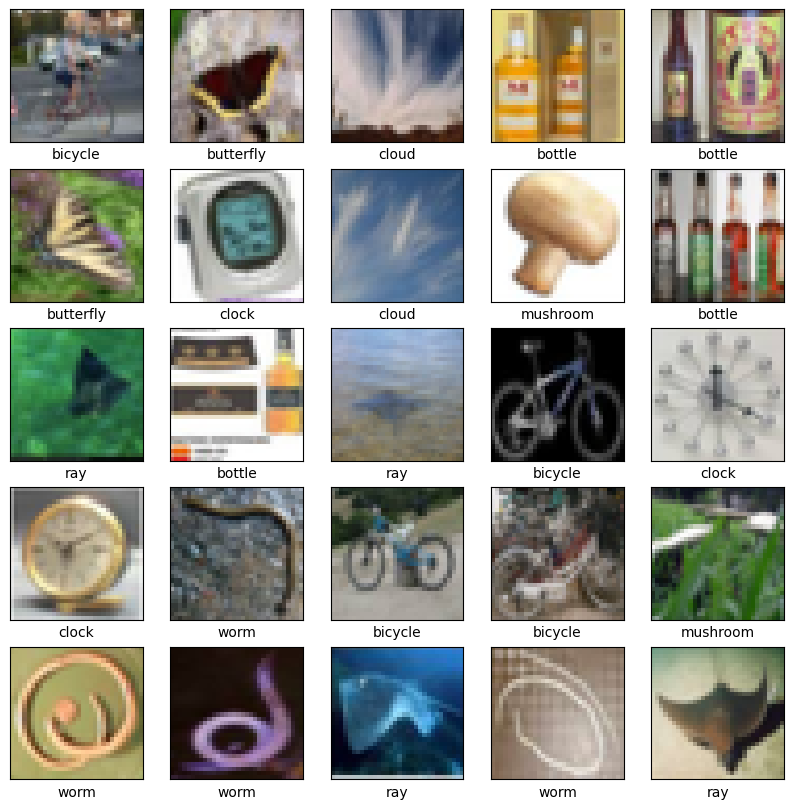

In [ ]:
# Show examples

plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_trn[i])
    plt.xlabel(sample_classes[y_trn[i]])
plt.show()

In [ ]:
# Model 1

model1 = build_model1('relu', 'adam', 0.001)
early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )

history1 = model1.fit(X_trn, y_trn,
                      epochs = 50,      # add more epochs
                      batch_size = 100,
                      callbacks = [early_stopping],
                      validation_data = (X_val, y_val)
                     )
best_val_acc1 = float(np.round(max(history1.history["val_accuracy"]), 4))
best_epoch1 = int(np.argmax(history1.history["val_accuracy"]))
_, test_acc1 = model1.evaluate(X_tst, y_tst, verbose = False)
print(f"Best validation accuracy: {best_val_acc1} at epoch {best_epoch1}")
print(f"Test accuracy: {test_acc1}")

Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 165ms/step - accuracy: 0.1972 - loss: 1.9900 - val_accuracy: 0.3300 - val_loss: 1.8473
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 164ms/step - accuracy: 0.3631 - loss: 1.6946 - val_accuracy: 0.3825 - val_loss: 1.6434
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 127ms/step - accuracy: 0.4131 - loss: 1.5696 - val_accuracy: 0.4125 - val_loss: 1.5470
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 126ms/step - accuracy: 0.4803 - loss: 1.4362 - val_accuracy: 0.5088 - val_loss: 1.3826
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 208ms/step - accuracy: 0.5206 - loss: 1.3489 - val_accuracy: 0.5425 - val_loss: 1.3321
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 124ms/step - accuracy: 0.5444 - loss: 1.2669 - val_accuracy: 0.5537 - val_loss: 1.2695
Epoch 7/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.5753 - loss: 1.1876 - val_accuracy: 0.5838 - val_loss: 1.2181
Epoch 8/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 199ms/step - accuracy: 0.5916 - loss: 1.1517 - val_accuracy: 0.

The increase of accuracy for model 1 architecture is:
$$0.5767 \to 0.665 \to 0.6938$$
(from the initial model through the model with the best hyperparameters on the other sample).

We can notice that model 6 achieves its best result with the same hyperparameters as in experiments above.

In [ ]:
# Model 6

model6 = build_model6('tanh', 'adam', 0.001)
early_stopping = callbacks.EarlyStopping(
                                          monitor = 'val_loss',
                                          patience = 5,
                                          restore_best_weights=True
                                        )

history6 = model6.fit(X_trn, y_trn,
                      epochs = 20,      # reduce epochs for shorter computation
                      batch_size = 20,
                      callbacks = [early_stopping],
                      validation_data = (X_val, y_val)
                     )
best_val_acc6 = float(np.round(max(history6.history["val_accuracy"]), 4))
best_epoch6 = int(np.argmax(history6.history["val_accuracy"]))
_, test_acc6 = model6.evaluate(X_tst, y_tst, verbose = False)
print(f"Best validation accuracy: {best_val_acc6} at epoch {best_epoch6}")
print(f"Test accuracy: {test_acc6}")

Epoch 1/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 128ms/step - accuracy: 0.4462 - loss: 1.5415 - val_accuracy: 0.5587 - val_loss: 1.2822
Epoch 2/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 21s 133ms/step - accuracy: 0.5944 - loss: 1.1484 - val_accuracy: 0.5913 - val_loss: 1.2211
Epoch 3/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 41s 135ms/step - accuracy: 0.6800 - loss: 0.9458 - val_accuracy: 0.6400 - val_loss: 1.0751
Epoch 4/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - accuracy: 0.7344 - loss: 0.7674 - val_accuracy: 0.6313 - val_loss: 1.0488
Epoch 5/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.7856 - loss: 0.6333 - val_accuracy: 0.6388 - val_loss: 1.0420
Epoch 6/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 23s 137ms/step - accuracy: 0.8353 - loss: 0.5088 - val_accuracy: 0.6300 - val_loss: 1.1091
Epoch 7/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.8694 - loss: 0.4069 - val_accuracy: 0.6575 - val_loss: 1.0077
Epoch 8/20
160/160 ━━━━━━━━━━━━━━━━━━━━ 20s 124ms/step - accuracy: 0.8884 - loss: 0

The increase of accuracy for model 6 architecture is:
$$0.5917 \to 0.67 \to 0.7125$$
(from the initial model through the model with the best hyperparameters).

# Conclusion

First, 6 different architecture were tested for fixed parameters: ReLU activation, Adam optimizer, learning rate 0.001, batch size 10, 16 epochs.
Two models were selected based on their test accuracy scores in those settings, a smaller and a larger one (model 2 and model 6 respectively):

* Model 2: test accuracy 0.615

* Model 6: test accuracy 0.5917

Then, with two selected architectures, different combinations of hyperparameters were tested. Due to the limitations of Google Colab, it appeared to be impossible to train and evaluate models for all parameter combinations by looping over them. For this reason a list of all parameter combinations was created and shuffled to get opportunity of trying a parameter setting independently of others and at the same time to get, from the very beginning, all parameters values participating (when looping you have to wait for another value of the parameter in the outer loop until all other parameters' values have been tried). Among other things, this made it possible to stop and remove "bad" values from consideration before they waste much time.

As a result, 50 training runs were executed for both architectures. The best parameter sets were determined as:

* Model 2: sigmoid activation, RMSprop optimizer, learning rate 0.001, batch size 20, epochs 24, which led to maximum validation accuracy of 0.5983 at epoch 22;

* Model 6: tanh activation, Adam optimizer, learning rate 0.001, batch size 20, epochs  24, which led to maximum validation accuracy of 0.6517 at epoch 10.

After that, these model (with the selected parameters) were retrained on all training  images of these 10 classes. The final scores for them are:

* Model 2: test accuracy 0.71

* Model 6: test accuracy 0.698

The experiments were repeated for another dataset. To speed up the process, the data was extracted from the same CIFAR-100 dataset. This time, different classes were selected, 8 in total, with 250/50/50 images per class for training/validation/testing purposes. The classes were chosen so that their objects would be more distinct from those of other classes.

The experiment settings were the same except for the following:

* another model architecture (model 1) occured to be a little better here. So, model 2 was replaced with model 1;

* hyperparameter choice was reduced by removing options for learnable rate and epochs (only one option for each was left), because other values didn't look prospective.

In total, there were 12 training-validation runs for each of two models.
The best parameter combinations were:

* Model 1: ReLU activation, Adam optimizer, (learning rate 0.001), batch size 20, (epochs 24), which led to maximum validation accuracy of 0.665 at epoch 23;

* Model 6: tanh activation, Adam optimizer, (learning rate 0.001), batch size 20, (epochs  24), which led to maximum validation accuracy of 0.67 at epoch 10.

For model 6, the best parameters are exactly the same as for the first run of experiments, which supports the previous results.
The only difference is the accuracy value, that is slightly higher for the new dataset (0.67 against 0.6517), probably due to class selection with more differing objects.

Retraining on 400 images per class and then evaluating on the test set yielded the following results:

* Model 1: test accuracy 0.6938

* Model 6: test accuracy 0.7125



### Some observations on hyperparameter choices

* *Adam* optimizer (with ReLU activation) gave very bad results when learning rate was 0.01 or higher. Due to this, 0.1 and 0.01 were removed from options for learning rate.

* *SGD* optimizer shows extremely bad performance (at least for the parameters provided: learning rate 0.0001–0.001, epochs < 25).
It was replaced by *RMSprop* which appeared to be good in some cases. It is somewhat similar to Adam. Both of them provide mediocre results (accuracy of 0.35–0.55) when used with model 2 while with model 6 the score is either > 0.54 or = 0.1. The latter case means that the model always predict one class (out of 10), i.e., it has failed to optimize its learnable parameters.

* *sigmoid* as activation function gives very bad results for larger models, but mediocre and rarely even good results for the small one (model 2).

* *tanh* and *ReLU* look similarly good options.

* 0.001 seems to be the optimal value for *learning rate* in all investigated cases.

* Increasing the number of *epochs* doesn't seem much helpful, because the loss decline often becomes very slow already within 20 epochs.

Other hyperparameters don't have definite quality. Their effect depends on combination with other parameters.

A few more remarks:

* Having a large number of learnable parameters doesn't itself improve performance. It seems that a smarter architecture is more important than size. For example, the smallest model 2 (in terms of learnable parameters) demonstrated the best results in several cases.
It's  not much possible to put more layers, though, because they usually shrink the dimensions of filtered images while this dataset has quite small image size (low resolution).

* It seems that dataset quality and size may affect the results even more than model architecture does: while the range of scores for different architectures was just about 0.8, training on all available images may augment accuracy rate for the same architecture by about 1.0 (model 2 case) or at least by 0.3-0.4, which is nevertheless comparable with between-architectures difference.

Overall, unfortunately, no parameter combination ended up with really good classifier. Probably, a better model requires larger number of layers, or larger layer sizes, or more training data. But this would require also even greater computational resources, that are not available.

However, hyperparameter tuning has noticeable effect on performance. Accuracy can grow by several persentage points.

Still, the score values are approximate. They seemingly depend on data samples. This is indicated by that sometimes test accuracy is lower than validation accuracy and sometimes vice versa. The difference may be about 0.01-0.03. Maybe the precision of results should be considered the same value.





_(After having finished, I noticed several points to be improved in the project work, like better data sampling and its usage for model evaluation, etc. But unfortunately it's not possible to redo the whole work due to the limited time left.)_